In [ ]:
import os
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import rankdata, norm, spearmanr
from scipy.interpolate import UnivariateSpline
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from pandas.plotting import register_matplotlib_converters

register_matplotlib_converters()

In [ ]:
# ==== CONFIGURATION ====
CSV_PATH = "wedowind.csv"
TOP_K = 7
TEST_PERIOD_DAYS = 20
RANDOM_STATE = 42
FI_THRESHOLD = 50.0

# Binary error code for failure detection
FAILURE_CODE = 1

In [ ]:
# Define original SCADA variables for feature selection
CANDIDATE_VARS = [
    'airpressure', 'humidity', 'bearing_temperature', 'temp_environment',
    'gear_pressure', 'nacelle_direction', 'wind_direction',
    'hydraulic_pressure', 'blade_angle_2', 'blade_angle_1',
    'cosphi', 'wind_speed', 'turbulence_intensity',
    'power', 'rotor_speed', 'generator_speed', 'temp_hydraulic_oil',
    'blade_angle_3'
]

In [ ]:
# Filtering variables for Mahalanobis
MAHALANOBIS_VARS = ['power', 'wind_speed']

In [ ]:
# ===== STEP 1: Load and Pre-process data =====
data = pd.read_csv(CSV_PATH, parse_dates=['timestamp'])
if 'Unnamed: 0' in data.columns:
    data.drop(columns=['Unnamed: 0'], inplace=True)

# Ensure essential columns exist
if 'plant_name' not in data.columns:
    raise KeyError("The CSV file must contain a 'plant_name' column.")
if 'errorcode' not in data.columns:
    raise KeyError("The CSV file must contain an 'errorcode' column.")

data.set_index('timestamp', inplace=True)
data.sort_index(inplace=True)

print(f"[Step 1] Loaded data: {data.shape[0]} rows, {data.shape[1]} columns")
unique_plants = data['plant_name'].unique()
print(f"Found {len(unique_plants)} unique plants: {list(unique_plants)}")

# Find the last failure date for each plant
last_failure_dates = {}
for plant_name in unique_plants:
    plant_df = data[data['plant_name'] == plant_name].copy()
    failure_events = plant_df[plant_df['errorcode'] == FAILURE_CODE]
    if not failure_events.empty:
        last_event_date = failure_events.index.max()
        last_failure_dates[plant_name] = last_event_date
        print(f"Found a failure event for Plant {plant_name} on: {last_event_date}")
    else:
        print(f"No failure events found for Plant {plant_name}.")

print("\nFinal dictionary of last failure dates:")
print(last_failure_dates)


In [24]:
for plant_name, failure_date in last_failure_dates.items():
    print(f"\n======== Processing Plant: {plant_name} (Failure Date: {failure_date}) ========")
    plant_df = data[data['plant_name'] == plant_name].copy()

    # Define date ranges
    test_start_date = failure_date - pd.Timedelta(days=TEST_PERIOD_DAYS)
    test_df_raw = plant_df.loc[test_start_date:failure_date].copy()
    learn_df_raw = plant_df.loc[:test_start_date].copy()

    # Data cleaning function
    def clean_data(df):
        df_clean = df.copy()
        # 1. Ensure key variables exist
        key_vars = ['power', 'wind_speed', 'rotor_speed']
        df_clean = df_clean.dropna(subset=key_vars, how='any')

        # 2. Basic operational filters
        df_clean = df_clean[
            (df_clean['power'] >= 0) &
            (df_clean['rotor_speed'] >= 0) &
            (df_clean['wind_speed'] >= 0)
        ]
        return df_clean

    learn_df = clean_data(learn_df_raw)
    test_df = clean_data(test_df_raw)

    print(f"Learn set size: {len(learn_df)}, Test set size: {len(test_df)}")

    # Feature selection - use all candidate vars that exist and have variation
    available_vars = [v for v in CANDIDATE_VARS if v in learn_df.columns]
    SELECTED_FEATURES = [v for v in available_vars if learn_df[v].nunique() > 1]

    if not SELECTED_FEATURES:
        print("No valid features with variation found. Skipping plant.")
        continue



======== Processing Plant: 109 (Failure Date: 2022-07-25 15:00:00) ========
Learn set size: 89886, Test set size: 1349

======== Processing Plant: 115 (Failure Date: 2022-07-28 13:00:00) ========
Learn set size: 95426, Test set size: 2526

======== Processing Plant: 120 (Failure Date: 2022-07-20 14:40:00) ========
Learn set size: 89123, Test set size: 2059

======== Processing Plant: 114 (Failure Date: 2022-07-18 13:00:00) ========
Learn set size: 87861, Test set size: 1773

======== Processing Plant: 116 (Failure Date: 2022-07-28 13:00:00) ========
Learn set size: 92793, Test set size: 2874


In [32]:
# ===== STEP 4: FI calculation and smoothing =====
learn_clean = learn_df[SELECTED_FEATURES]
test_clean = test_df[SELECTED_FEATURES]

scaler = StandardScaler()
Xs_learn = scaler.fit_transform(learn_clean)

# Handle potential constant features after scaling
constant_mask = np.std(Xs_learn, axis=0) == 0
if np.any(constant_mask):
    print(f"Removing constant features: {np.array(SELECTED_FEATURES)[constant_mask]}")
    Xs_learn = Xs_learn[:, ~constant_mask]
    Xs_test = scaler.transform(test_clean)[:, ~constant_mask]
    SELECTED_FEATURES = list(np.array(SELECTED_FEATURES)[~constant_mask])
else:
    Xs_test = scaler.transform(test_clean)

# Calculate Z-scores and fit GMM
Z_learn = norm.ppf(np.clip((rankdata(Xs_learn, axis=0) - 0.5) / Xs_learn.shape[0], 1e-6, 1 - 1e-6))
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=RANDOM_STATE)
gmm.fit(Z_learn)

# Calculate FI scores for test data
Z_test = norm.ppf(np.clip((rankdata(Xs_test, axis=0) - 0.5) / Xs_test.shape[0], 1e-6, 1 - 1e-6))
logp_test = gmm.score_samples(Z_test)
FI_test = (1.0 - ((rankdata(logp_test) - 0.5) / len(logp_test))) * 100



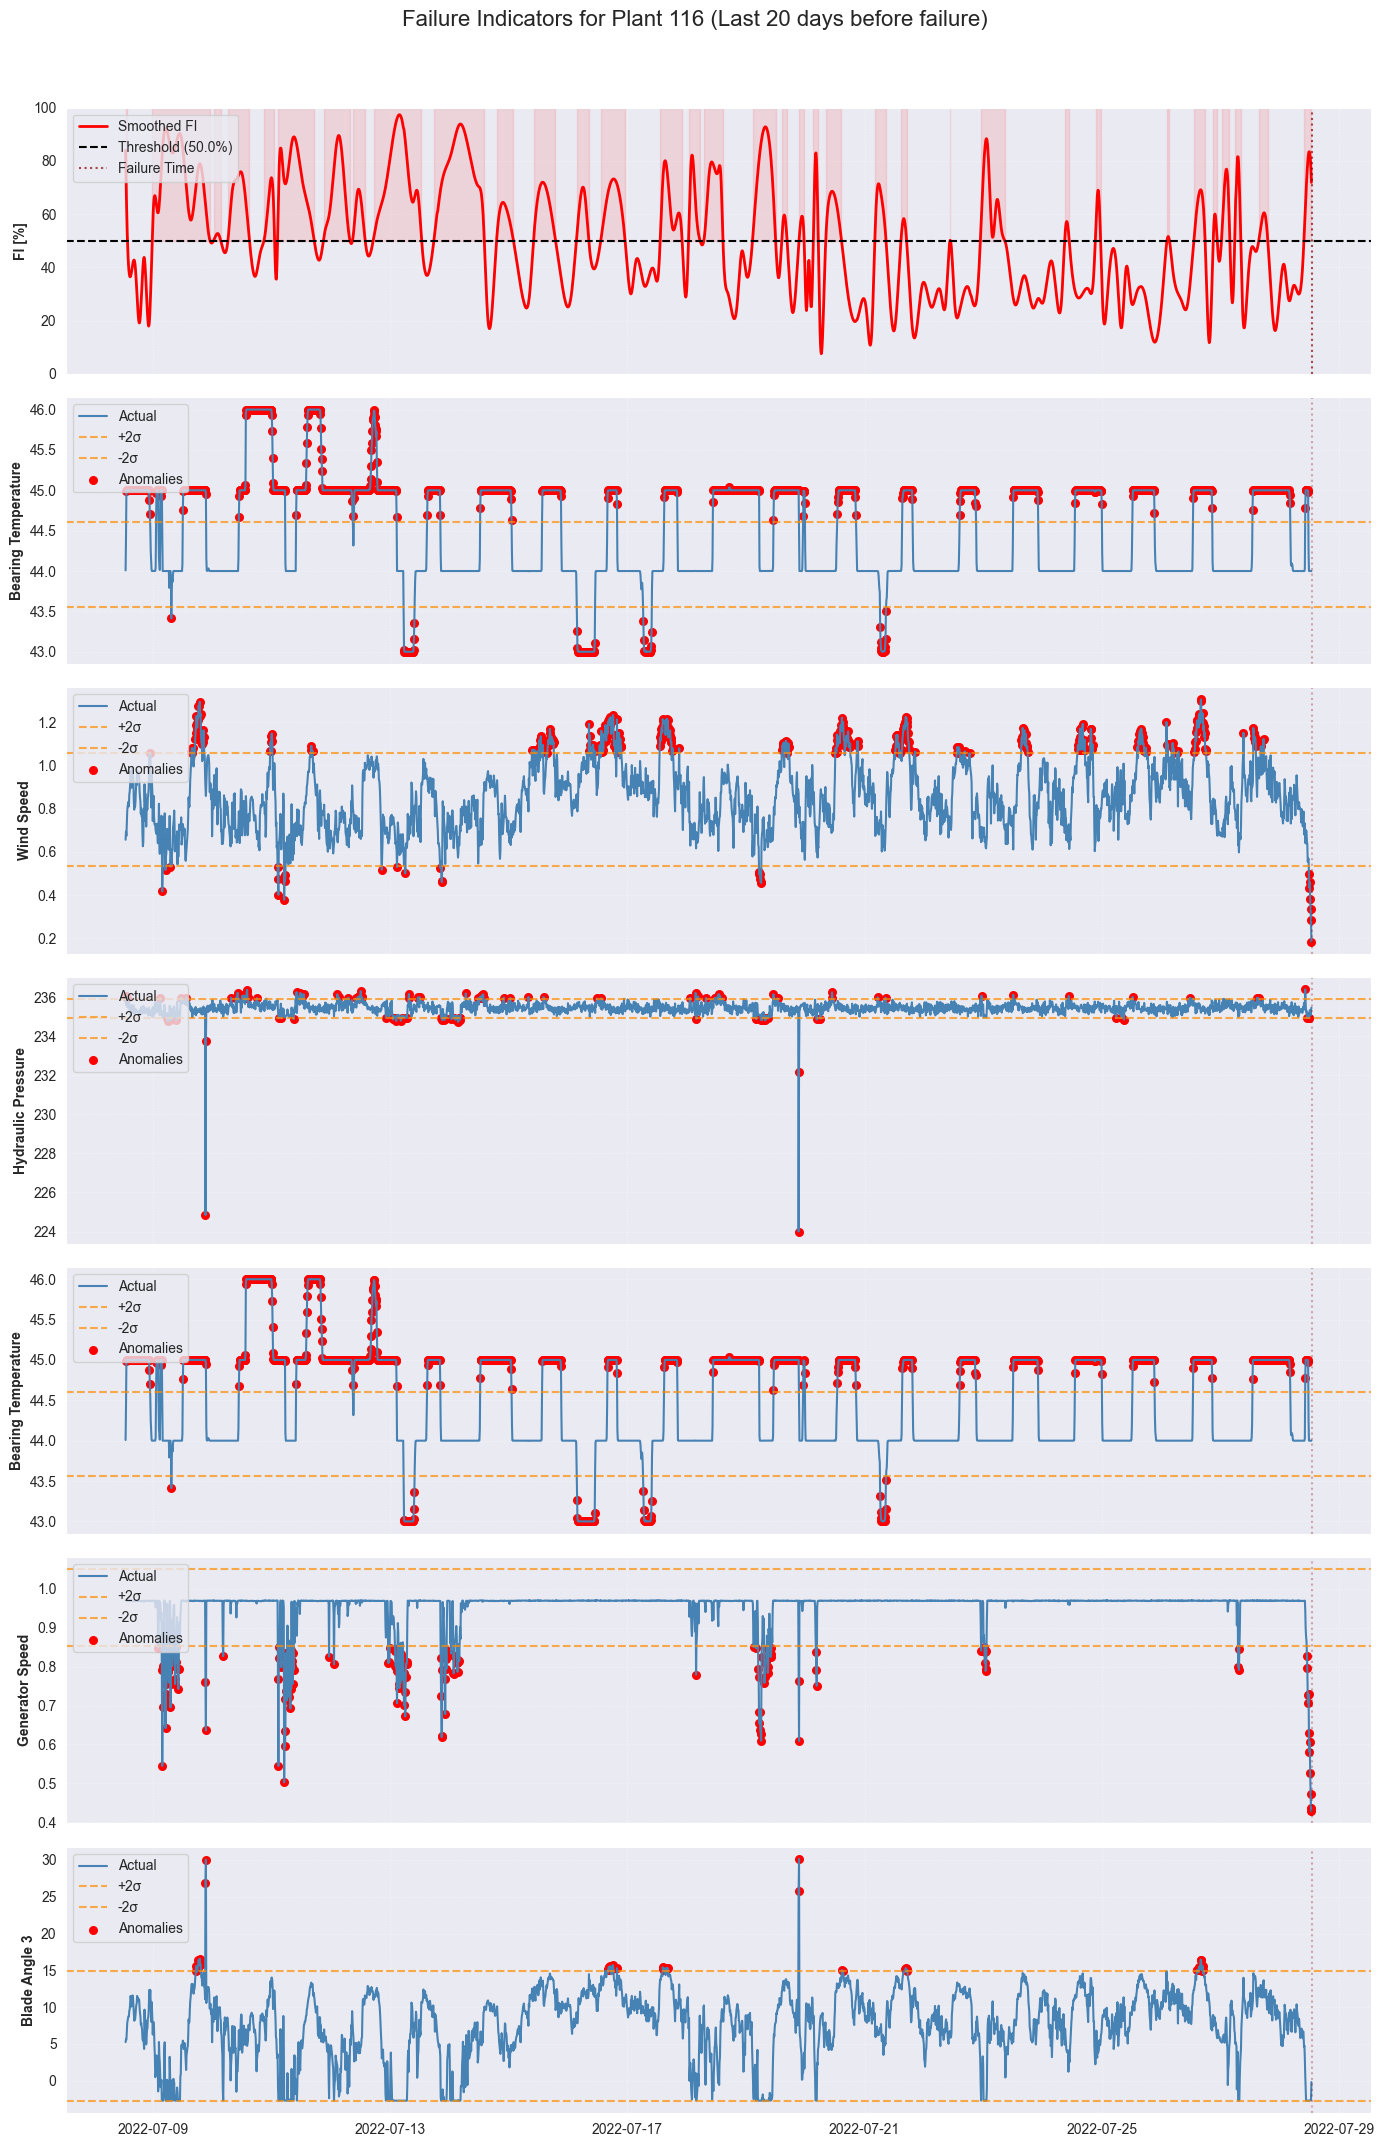


Key statistics near failure:
       bearing_temperature  wind_speed  hydraulic_pressure  \
count           144.000000  144.000000          144.000000   
mean             44.697558    0.850502          235.453820   
std               0.450019    0.165970            0.231747   
min              44.000000    0.185146          234.918304   
25%              44.023393    0.775690          235.319099   
50%              45.000000    0.858722          235.448051   
75%              45.000000    0.956708          235.601074   
max              45.000000    1.172734          236.401703   

       bearing_temperature  generator_speed  blade_angle_3  
count           144.000000       144.000000     144.000000  
mean             44.697558         0.938556       8.093320  
std               0.450019         0.103868       4.343770  
min              44.000000         0.428216      -2.704967  
25%              44.023393         0.969004       6.577793  
50%              45.000000         0.969385  

In [37]:
# Smooth the FI scores
if len(FI_test) > 1:
    SPLINE_SMOOTHING_FACTOR = len(FI_test) * np.var(FI_test) * 0.5  # Adjust multiplier as needed
    spl = UnivariateSpline(np.arange(len(FI_test)), FI_test, k=3, s=SPLINE_SMOOTHING_FACTOR)
    FI_test_s = spl(np.arange(len(FI_test)))
else:
    FI_test_s = FI_test

# Select features that are most likely to show failure patterns
failure_indicator_features = [
    'bearing_temperature',
    'wind_speed',
    'hydraulic_pressure',
    'bearing_temperature',
    'generator_speed',
    'blade_angle_3'
]

# Create figure with more subplots
n_vars_to_plot = min(6, len(SELECTED_FEATURES))  # Increased from 4 to 6
fig, axes = plt.subplots(n_vars_to_plot + 1, 1, figsize=(14, 3 * (n_vars_to_plot + 1)), sharex=True)
fig.suptitle(f"Failure Indicators for Plant {plant_name} (Last {TEST_PERIOD_DAYS} days before failure)",
             fontsize=16, y=1.02)

# 1. Plot FI scores with enhanced visualization
ax = axes[0]
ax.plot(test_df.index, FI_test_s, color='red', linewidth=2, label='Smoothed FI')
ax.axhline(FI_THRESHOLD, linestyle='--', color='black', label=f'Threshold ({FI_THRESHOLD}%)')
ax.axvline(failure_date, color='darkred', linestyle=':', alpha=0.7, label='Failure Time')

# Highlight the danger zone
ax.fill_between(test_df.index, FI_THRESHOLD, 100,
                where=(FI_test_s >= FI_THRESHOLD),
                color='red', alpha=0.1)

ax.set_ylabel('FI [%]', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(loc='upper left')
ax.set_ylim(0, 100)

# 2. Plot selected features with anomaly detection
for i, var in enumerate(failure_indicator_features[:n_vars_to_plot], start=1):
    if var in test_df.columns:
        ax = axes[i]

        # Calculate rolling z-score for anomaly detection
        rolling_mean = learn_df[var].rolling('24h').mean()
        rolling_std = learn_df[var].rolling('24h').std()
        z_score = (test_df[var] - rolling_mean[-1]) / rolling_std[-1]

        # Plot the feature values
        ax.plot(test_df.index, test_df[var], color='steelblue', label='Actual')

        # Plot 2σ thresholds from learn period
        ax.axhline(rolling_mean[-1] + 2*rolling_std[-1],
                  color='darkorange', linestyle='--', alpha=0.7, label='+2σ')
        ax.axhline(rolling_mean[-1] - 2*rolling_std[-1],
                  color='darkorange', linestyle='--', alpha=0.7, label='-2σ')

        # Highlight anomalies
        anomalies = np.where(np.abs(z_score) > 2)[0]
        if len(anomalies) > 0:
            ax.scatter(test_df.index[anomalies], test_df[var].iloc[anomalies],
                      color='red', s=30, label='Anomalies')

        ax.set_ylabel(var.replace('_', ' ').title(), fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(loc='upper left')

        # Add failure line to each subplot
        ax.axvline(failure_date, color='darkred', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()

# Additional diagnostic information
print("\nKey statistics near failure:")
failure_window = test_df.last('24h')
print(failure_window[failure_indicator_features].describe())

print("\nMaximum FI scores:")
max_fi_idx = np.argsort(FI_test_s)[-3:]  # Top 3 highest FI points
for idx in max_fi_idx:
    print(f"{test_df.index[idx]}: {FI_test_s[idx]:.1f}%")
    print(test_df.iloc[idx][failure_indicator_features])